# RAG (Retrieval-Augmented Generation) Learning Guide for Beginners

## A Comprehensive Introduction to RAG Architecture and Concepts

---

## 1. What is RAG?

### Definition
**RAG (Retrieval-Augmented Generation)** is a technique that combines two key AI capabilities:

1. **Retrieval**: Finding relevant information from a knowledge base or document collection
2. **Generation**: Using a Language Model (LLM) to generate natural language responses

### Simple Analogy
Imagine you're writing an essay on a topic. Instead of relying solely on your memory (like traditional LLMs), you:
- **First**, search your library for relevant books and documents (Retrieval)
- **Then**, use those documents to write a well-informed essay (Generation)

### Core Concept
RAG augments (enhances) the generation capability of LLMs by providing them with **relevant external information** before they generate responses.

### Key Benefit
RAG allows LLMs to generate more **accurate, up-to-date, and contextual** responses by grounding them in retrieved knowledge.

## 2. Problems with Large Language Models (LLMs)

### Problem 1: Knowledge Cutoff
- **Issue**: LLMs are trained on data up to a specific date. Any events or information after that date is unknown to them.
- **Example**: A model trained in early 2023 won't know about events that happened in late 2024.
- **Impact**: Users get outdated or incorrect information about recent events.

### Problem 2: Limited Context Window
- **Issue**: LLMs can only process a limited amount of text at once (context window). This limits how much information they can consider.
- **Example**: A model with a 4K token limit can't fully understand a 100-page document.
- **Impact**: Models miss important context for detailed questions.

### Problem 3: Domain-Specific Knowledge
- **Issue**: LLMs may not have deep expertise in specific domains (e.g., internal company policies, proprietary data).
- **Example**: A general LLM won't know your company's specific product documentation.
- **Impact**: Users get generic responses instead of domain-specific answers.

### Problem 4: No Access to Private Data
- **Issue**: LLMs can't access proprietary, confidential, or personal data.
- **Example**: An LLM can't read your private emails or internal documents.
- **Impact**: Users can't use LLMs with their sensitive business data.

### Problem 5: Static Knowledge
- **Issue**: Once trained, LLM knowledge is fixed. Updating knowledge requires retraining, which is expensive.
- **Example**: To include new product information, you'd need to retrain the entire model.
- **Impact**: Maintaining up-to-date knowledge is costly and time-consuming.

### Visual Summary
```
Traditional LLM Problems:
┌─────────────────────────────────────────────┐
│  LLM trained on fixed data                  │
│  - Only knows what it was trained on        │
│  - Can't access new information             │
│  - Can't access private data                │
│  - Limited context window                   │
│  - Expensive to update knowledge            │
└─────────────────────────────────────────────┘
```

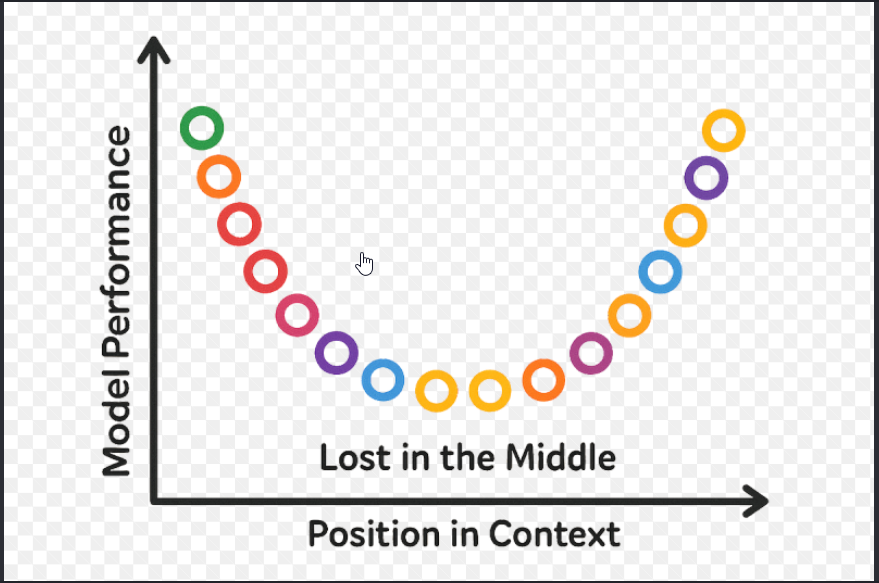

## 3. Hallucination in LLMs

### What is Hallucination?
**Hallucination** occurs when an LLM generates plausible-sounding but **false or fabricated information** as if it were fact.

### Key Characteristics
- **Confidence**: The model presents hallucinated information confidently and authoritatively
- **Plausibility**: The false information sounds reasonable and coherent
- **Unintentional**: The model isn't deliberately lying; it's following patterns in its training data

### Types of Hallucinations

#### Type 1: Factual Hallucination
- **Definition**: Making up facts that don't exist
- **Example**: "Albert Einstein was an astronaut" (False)
- **Impact**: Users receive incorrect information presented as truth

#### Type 2: Source Hallucination
- **Definition**: Inventing citations or sources that don't exist
- **Example**: Citing a paper title that was never written
- **Impact**: Misleading users about information origin

#### Type 3: Contextual Hallucination
- **Definition**: Making up details that contradict provided context
- **Example**: User says "I have 3 pets" but the model later says "your 5 pets"
- **Impact**: Ignoring or contradicting user input

#### Type 4: Logical Hallucination
- **Definition**: Making false logical connections or conclusions
- **Example**: "All birds can fly, penguins are birds, therefore penguins are good fliers" (False)
- **Impact**: Invalid reasoning leading to wrong conclusions

### Why Do Hallucinations Occur?

1. **Statistical Patterns**: LLMs learn statistical patterns from training data, not true understanding
2. **Prediction Over Knowledge**: Models predict probable next words, not verify facts
3. **Training Data Gaps**: If training data lacks information, the model extrapolates or guesses
4. **Confidence Issues**: Models don't distinguish between confident knowledge and uncertain guesses

### Real-World Example
```
User Question: "What are the main features of product X?"

Without RAG (Prone to Hallucination):
"Product X features include: advanced AI integration, real-time analytics,
blockchain security, and quantum computing capabilities."
(Some of these might be completely made up!)

With RAG (Grounded in Facts):
"Based on the official documentation, Product X features include:
advanced reporting, API integration, and user management."
(Only information from actual documentation is used)
```

### Visual Representation
```
Hallucination Risk:
┌─────────────────────────┐
│  LLM generates output   │
│  WITHOUT external facts │
│        │                │
│        ▼                │
│   ❌ Hallucination      │
│   (Made-up facts)       │
└─────────────────────────┘
```

## 4. Why We Need RAG and How It Resolves Problems

### The Solution: RAG Framework
RAG directly addresses the limitations of traditional LLMs by grounding responses in **retrieved factual information**.

### How RAG Solves Each Problem

#### Problem 1: Knowledge Cutoff → SOLVED by RAG
**How**:
- Retrieve the latest information from up-to-date knowledge bases
- Feed current information to the LLM for generation
- LLM uses retrieved facts instead of relying on outdated training data

**Result**: Up-to-date responses even about recent events

#### Problem 2: Limited Context Window → SOLVED by RAG
**How**:
- Retrieval system intelligently fetches only the most relevant excerpts
- Instead of processing entire documents, LLM processes focused summaries
- Reduces token usage while maintaining context quality

**Result**: Can handle vast knowledge bases without exceeding token limits

#### Problem 3: Domain-Specific Knowledge → SOLVED by RAG
**How**:
- Create knowledge bases with domain-specific documents and data
- Retrieve relevant domain knowledge before generation
- LLM specializes in specific domains through targeted retrieval

**Result**: Expert-level responses in specific domains

#### Problem 4: No Access to Private Data → SOLVED by RAG
**How**:
- Build knowledge bases with your private, proprietary data
- Data stays secure in your controlled environment
- Only query results are sent to the LLM, not raw data

**Result**: Can use LLMs with sensitive business data securely

#### Problem 5: Static Knowledge → SOLVED by RAG
**How**:
- Update knowledge base documents without retraining the LLM
- New information is immediately available through retrieval
- No expensive model retraining needed

**Result**: Easy, quick, and cost-effective knowledge updates

### Hallucination Reduction
**How RAG Reduces Hallucinations**:
1. **Grounding**: LLM must base responses on retrieved facts
2. **Fact-Checking**: Generated text can reference source documents
3. **Limited Creativity**: LLM focuses on synthesizing retrieved info, not inventing
4. **Explainability**: Users can see which documents informed the response

### Before and After RAG
```
BEFORE RAG (Traditional LLM):
User: "What's the return policy?"
LLM:  "Our return policy is 30 days" (Might be outdated or wrong)
      └─ No source, might be hallucinated

AFTER RAG:
User: "What's the return policy?"
RAG:  1. Retrieves latest policy document
      2. Extracts: "45 days with original receipt"
      3. LLM generates: "Our return policy allows 45 days with the
                       original receipt as per our updated policy."
      └─ Grounded in actual documents, verified and up-to-date
```

### Why RAG is Essential
```
Traditional LLM → RAG System
      ❌              ✅
   Outdated         Current
   Generic          Specific
  Hallucinated      Grounded
  No sources        Cited sources
  Static            Dynamic
  Expensive update  Easy update
```

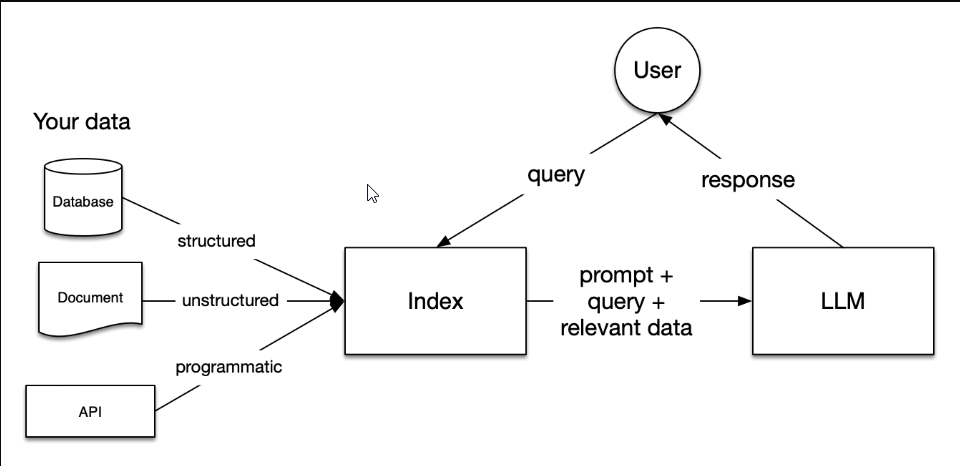

## 5. RAG Architecture and Components

### Overall RAG Architecture

```
┌──────────────────────────────────────────────────────────────┐
│                    RAG SYSTEM ARCHITECTURE                    │
├──────────────────────────────────────────────────────────────┤
│                                                               │
│  OFFLINE PHASE (Preparation)                                 │
│  ┌────────────────────────────────────────────────┐          │
│  │ 1. Data Collection                             │          │
│  │    └─ Gather documents, PDFs, databases, etc. │          │
│  │                                                │          │
│  │ 2. Document Processing                         │          │
│  │    └─ Clean, format, and prepare data         │          │
│  │                                                │          │
│  │ 3. Chunking                                    │          │
│  │    └─ Split documents into small pieces       │          │
│  │                                                │          │
│  │ 4. Embedding                                   │          │
│  │    └─ Convert text to numerical vectors       │          │
│  │                                                │          │
│  │ 5. Vector Database Storage                     │          │
│  │    └─ Store embeddings for quick retrieval    │          │
│  └────────────────────────────────────────────────┘          │
│                          │                                    │
│                          ▼                                    │
│  ┌────────────────────────────────────────────────┐          │
│  │        VECTOR DATABASE (Knowledge Base)        │          │
│  │  - Stored embeddings                           │          │
│  │  - Original text chunks                        │          │
│  │  - Metadata (source, date, etc.)               │          │
│  └────────────────────────────────────────────────┘          │
│                                                               │
│  ONLINE PHASE (Runtime)                                      │
│  ┌────────────────────────────────────────────────┐          │
│  │ User Query Input                               │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ 1. Query Embedding                             │          │
│  │    └─ Convert user question to vector         │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ 2. Similarity Search (Retrieval)               │          │
│  │    └─ Find most relevant document chunks      │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ 3. Retrieved Documents                         │          │
│  │    └─ Top K most relevant chunks              │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ 4. Context Building                            │          │
│  │    └─ Combine retrieved docs + user query     │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ 5. LLM Generation (Augmented)                  │          │
│  │    └─ Generate response using context         │          │
│  │        │                                       │          │
│  │        ▼                                       │          │
│  │ Final Response with Sources                    │          │
│  └────────────────────────────────────────────────┘          │
│                                                               │
└──────────────────────────────────────────────────────────────┘
```

### Core Components Detailed

---

### Component 1: Data Ingestion
**Purpose**: Collect and prepare source documents

**What it does**:
- Gathers documents from various sources (PDFs, websites, databases, APIs, etc.)
- Extracts text and metadata from different formats
- Validates and cleans the data

**Input**: Raw documents in any format

**Output**: Cleaned, structured text documents

**Example**:
```
Input: "research_paper.pdf", "website.html", "database.csv"
        ↓
Output: ["Extracted text from PDF...", "Extracted text from web...", ...]
```

---

### Component 2: Text Chunking
**Purpose**: Break large documents into manageable pieces

**What it does**:
- Splits long documents into smaller chunks (usually 256-1024 tokens)
- Maintains context by overlapping chunk boundaries
- Preserves metadata (document source, page number, etc.)

**Why it's important**:
- Large documents don't fit well in embeddings
- Smaller chunks improve retrieval accuracy
- Overlapping prevents losing context at boundaries

**Example**:
```
Original Document (1000 words):
"The climate change report states that...
 Global temperatures have risen by...
 This trend is accelerating because...
 Solutions include renewable energy..."

After Chunking (overlap of ~50 words):
Chunk 1: "The climate change report states that...
          Global temperatures have risen by..."

Chunk 2: "Global temperatures have risen by...
          This trend is accelerating because..."

Chunk 3: "This trend is accelerating because...
          Solutions include renewable energy..."
```

---

### Component 3: Embedding Model
**Purpose**: Convert text to numerical representations that capture meaning

**What it does**:
- Transforms text chunks into high-dimensional vectors (embeddings)
- Captures semantic meaning of text
- Similar texts produce similar vector representations

**How embeddings work**:
- Words with similar meanings have vectors close together
- "car" and "automobile" have similar embeddings
- "car" and "elephant" have different embeddings

**Popular embedding models**:
- OpenAI's text-embedding-3-large
- Google's PaLM Embedding
- Open-source: Sentence-BERT, BGE

**Example**:
```
Text: "The dog ran quickly"
      ↓
Embedding: [0.23, -0.45, 0.89, 0.12, ..., -0.34]  (384-1536 dimensions)

Text: "The puppy sprinted fast"
      ↓
Embedding: [0.24, -0.46, 0.88, 0.13, ..., -0.35]  (Similar vector!)
```

---

### Component 4: Vector Database
**Purpose**: Store and efficiently search through embeddings

**What it does**:
- Stores embeddings in a specialized index
- Enables fast similarity search (millisecond response times)
- Stores metadata alongside embeddings for source tracking

**Why not use regular databases?**
- Regular databases search by exact matches
- Vector databases search by semantic similarity
- Vector databases use specialized algorithms (HNSW, IVF) for speed

**Popular vector databases**:
- Pinecone (cloud-based, managed)
- Weaviate (open-source, flexible)
- Milvus (open-source, high-performance)
- FAISS (Facebook's library, lightweight)
- Chromadb (simple, embeddable)
- Qdrant (modern, production-ready)

**Storage structure**:
```
Vector Database Structure:
┌─────────────────────────────────────┐
│ ID  │ Embedding Vector │ Metadata    │
├─────────────────────────────────────┤
│ 1   │ [0.23, -0.45...]│ source.pdf  │
│ 2   │ [0.24, -0.46...]│ page_5.txt  │
│ 3   │ [0.15, -0.30...]│ doc2.pdf    │
│ ... │ ...              │ ...         │
└─────────────────────────────────────┘
```

---

### Component 5: Retrieval Engine
**Purpose**: Find the most relevant documents for a query

**What it does**:
1. Converts user query into an embedding
2. Searches vector database for similar embeddings
3. Returns top-K most relevant chunks (typically K=3-5)

**Retrieval process**:
```
User Query: "How do I reset my password?"
            ↓
Query Embedding: [0.18, -0.41, 0.92, ...]
            ↓
Similarity Search in Vector DB:
  Chunk 1: similarity = 0.92 ✓ (Most relevant)
  Chunk 2: similarity = 0.87 ✓
  Chunk 3: similarity = 0.85 ✓
  Chunk 4: similarity = 0.42 ✗ (Not relevant)
            ↓
Retrieved Chunks (Top-3):
  "To reset your password, click Forgot Password on the login page..."
  "Password reset requires email verification..."
  "For security, passwords must be 8+ characters..."
```

**Retrieval strategies**:
- **Dense Retrieval**: Uses semantic similarity (most common)
- **Sparse Retrieval**: Uses keyword matching (BM25)
- **Hybrid Retrieval**: Combines both methods for better results

---

### Component 6: Prompt Engineering / Context Window
**Purpose**: Format retrieved information to give LLM the best context

**What it does**:
- Combines user query with retrieved documents
- Structures prompt to guide LLM generation
- Adds instructions for source citation

**Prompt structure**:
```
┌─────────────────────────────────────────┐
│ System Instructions                     │
│ "You are a helpful assistant..."        │
├─────────────────────────────────────────┤
│ Retrieved Context                       │
│ "Based on the following documents:      │
│  [Document 1]                           │
│  [Document 2]                           │
│  [Document 3]"                          │
├─────────────────────────────────────────┤
│ User Question                           │
│ "What is the return policy?"            │
├─────────────────────────────────────────┤
│ Instructions                            │
│ "Answer using only the provided docs.   │
│  Include source references."            │
└─────────────────────────────────────────┘
```

---

### Component 7: Language Model (LLM)
**Purpose**: Generate contextual responses based on retrieved information

**What it does**:
- Receives the prompt with context
- Understands retrieved documents
- Generates natural language response grounded in the context

**Popular LLMs for RAG**:
- OpenAI GPT-4, GPT-3.5-turbo
- Google Gemini
- Meta Llama 2/3
- Anthropic Claude
- Open-source: Mistral, Zephyr

**Key advantage in RAG**:
- Instead of relying on training data, uses retrieved context
- Reduces hallucination significantly
- Can cite sources from retrieved documents

---

### Component 8: Response Generation & Post-Processing
**Purpose**: Format and enhance the generated response

**What it does**:
- Refines the LLM output
- Adds source citations
- Formats for user readability
- May rank or score alternative responses

**Output example**:
```
Answer: "You can reset your password by visiting the login page
         and clicking 'Forgot Password'. You'll receive an email
         with reset instructions."

Sources:
  1. docs/user-guide.pdf - Section 3.2
  2. docs/FAQ.md - "Password Issues"

Confidence: 95%
```

---

### Component Summary Table

| Component | Purpose | Input | Output |
|-----------|---------|-------|--------|
| **Data Ingestion** | Collect documents | Raw files | Cleaned text |
| **Text Chunking** | Split documents | Large documents | Small chunks |
| **Embedding Model** | Convert to vectors | Text chunks | Vector embeddings |
| **Vector Database** | Store embeddings | Embeddings | Indexed storage |
| **Retrieval Engine** | Find relevant docs | Query + DB | Top-K chunks |
| **Prompt Engineering** | Format context | Query + Chunks | Formatted prompt |
| **LLM** | Generate response | Prompt | Generated text |
| **Post-Processing** | Format output | LLM response | Final answer |


## 6. Working of RAG (Step-by-Step Process)

### Complete RAG Workflow

RAG operates in two main phases: **Offline Preparation** and **Online Execution**.

---

## PHASE 1: OFFLINE PREPARATION (Setup)

This phase happens once during system setup and whenever you add new documents.

### Step 1: Document Collection
**What happens**:
- Gather all documents that will serve as the knowledge base
- Documents can be: PDFs, web pages, markdown files, databases, APIs, etc.
- Store them in a central location

**Example**:
```
Collecting Documents:
- product_manual.pdf (50 pages)
- FAQ.md (100 Q&As)
- support_articles/ (500 articles)
- knowledge_base.json (structured data)
- company_policies.docx (policies)
```

### Step 2: Data Preprocessing
**What happens**:
- Extract text from different file formats
- Remove noise (HTML tags, extra whitespace, etc.)
- Normalize text (handle special characters, language-specific issues)
- Remove duplicate content

**Example**:
```
Raw: "<h1>Product Info</h1><p>  This is a   product</p>"
      ↓
Clean: "Product Info. This is a product"
```

### Step 3: Document Chunking
**What happens**:
- Divide documents into smaller, meaningful chunks
- Typical chunk size: 256-1024 tokens (roughly 100-400 words)
- Create overlap between chunks to maintain context

**Chunking strategy**:
```
Document:
"The company was founded in 2010. It started with 5 employees.
 By 2015, the company had grown to 50 employees. In 2020,
 it expanded internationally. Today, it has 500+ employees worldwide."

Chunks (with 50% overlap):

Chunk 1:
"The company was founded in 2010. It started with 5 employees.
 By 2015, the company had grown to 50 employees."

Chunk 2:
"By 2015, the company had grown to 50 employees. In 2020,
 it expanded internationally."

Chunk 3:
"In 2020, it expanded internationally. Today, it has 500+ employees
 worldwide."
```

### Step 4: Generate Embeddings
**What happens**:
- Convert each chunk into a vector embedding
- Use an embedding model (e.g., OpenAI's text-embedding-3-large)
- Each chunk becomes a point in high-dimensional space

**Embedding process**:
```
Chunk 1: "The company was founded in 2010..."
         ↓ (Embedding Model)
Vector:  [0.123, -0.456, 0.789, ..., 0.234] (1536 dimensions)

Chunk 2: "By 2015, the company had grown..."
         ↓ (Embedding Model)
Vector:  [0.125, -0.460, 0.785, ..., 0.240] (Similar vector)

Chunk 3: "In 2020, it expanded internationally..."
         ↓ (Embedding Model)
Vector:  [0.110, -0.470, 0.780, ..., 0.250] (Different vector)
```

### Step 5: Store in Vector Database
**What happens**:
- All embeddings are indexed in a vector database
- Database optimizes for fast similarity search
- Metadata is stored alongside embeddings

**Storage structure**:
```
Vector Database Index:

┌──────────────┬────────────────────────┬──────────────────┐
│ Chunk ID     │ Embedding Vector       │ Metadata         │
├──────────────┼────────────────────────┼──────────────────┤
│ chunk_001    │ [0.123, -0.456, ...]   │ source: doc1.pdf │
│              │                        │ page: 1          │
├──────────────┼────────────────────────┼──────────────────┤
│ chunk_002    │ [0.125, -0.460, ...]   │ source: doc1.pdf │
│              │                        │ page: 2          │
├──────────────┼────────────────────────┼──────────────────┤
│ chunk_003    │ [0.110, -0.470, ...]   │ source: doc2.pdf │
│              │                        │ page: 5          │
└──────────────┴────────────────────────┴──────────────────┘
```

**Offline Phase Complete!**
```
Ready for queries with a fully prepared knowledge base.
```

---

## PHASE 2: ONLINE EXECUTION (Runtime)

This phase happens every time a user submits a question.

### Step 6: User Query Input
**What happens**:
- User submits a natural language question
- System receives and validates the input

**Example**:
```
User Question: "When was the company founded and how many employees does it have?"
```

### Step 7: Query Embedding
**What happens**:
- The user's query is converted into an embedding
- Uses the **same embedding model** as offline phase
- Creates a vector in the same space as document embeddings

**Process**:
```
User Query: "When was the company founded and how many employees does it have?"
            ↓ (Same Embedding Model)
Query Vector: [0.120, -0.450, 0.790, ..., 0.235]  (1536 dimensions)
```

### Step 8: Similarity Search (Retrieval)
**What happens**:
- Query vector is compared to all document vectors in the database
- Similarity is calculated using distance metrics (cosine similarity, L2, etc.)
- Top-K most similar chunks are retrieved (usually K=3-5)

**Similarity calculation**:
```
Query Vector:          [0.120, -0.450, 0.790, ...]

Comparison with chunks in database:

Chunk 1: [0.123, -0.456, 0.789, ...]
         Similarity Score: 0.98 ✓✓✓ (Most similar - RETRIEVED)

Chunk 2: [0.125, -0.460, 0.785, ...]
         Similarity Score: 0.96 ✓✓ (Very similar - RETRIEVED)

Chunk 3: [0.110, -0.470, 0.780, ...]
         Similarity Score: 0.94 ✓ (Similar - RETRIEVED)

Chunk 4: [-0.50, 0.60, -0.20, ...]
         Similarity Score: 0.15 ✗ (Not similar - NOT RETRIEVED)

Chunk 5: [0.20, 0.30, 0.40, ...]
         Similarity Score: 0.22 ✗ (Not similar - NOT RETRIEVED)
```

**Result: Top 3 Most Relevant Chunks Retrieved**

### Step 9: Build Augmented Prompt
**What happens**:
- Combine retrieved documents with the original query
- Create a well-structured prompt for the LLM
- Add instructions for response generation

**Prompt construction**:
```
┌──────────────────────────────────────────────────────┐
│ SYSTEM PROMPT                                        │
│ "You are a helpful assistant. Answer questions      │
│  based ONLY on the provided documents. If the       │
│  document doesn't contain the answer, say so."     │
├──────────────────────────────────────────────────────┤
│ RETRIEVED CONTEXT                                    │
│                                                      │
│ Document 1:                                          │
│ "The company was founded in 2010. It started with   │
│  5 employees."                                      │
│                                                      │
│ Document 2:                                          │
│ "By 2015, the company had grown to 50 employees."   │
│                                                      │
│ Document 3:                                          │
│ "Today, the company has 500+ employees worldwide."  │
├──────────────────────────────────────────────────────┤
│ USER QUESTION                                        │
│ "When was the company founded and how many          │
│  employees does it have?"                           │
├──────────────────────────────────────────────────────┤
│ INSTRUCTIONS                                         │
│ "Cite the specific document sections that support   │
│  your answer."                                      │
└──────────────────────────────────────────────────────┘
```

### Step 10: LLM Generates Response
**What happens**:
- LLM reads the augmented prompt
- Understands the context from retrieved documents
- Generates a natural language response
- Response is grounded in the retrieved facts

**LLM Processing**:
```
LLM receives:
├─ System instructions
├─ 3 relevant document chunks
├─ User question
└─ Citation requirements
        ↓
LLM reasoning:
"The documents say:
 - Founded in 2010
 - Currently has 500+ employees
 The user asked for both pieces of information.
 I should answer with both facts."
        ↓
Generated Response:
"The company was founded in 2010 and started with 5 employees.
 Today, it has 500+ employees worldwide."
```

### Step 11: Post-Processing & Formatting
**What happens**:
- Add source citations
- Format response for readability
- Add confidence scores if applicable
- Rank alternative responses

**Final Output**:
```
FINAL RESPONSE TO USER:

Answer:
"The company was founded in 2010 and started with just 5 employees.
 Through consistent growth, it expanded to 50 employees by 2015.
 Today, the company has grown to 500+ employees with a global presence."

Source Documents:
  [1] Company History Section (doc1.pdf, page 1)
  [2] Timeline Overview (doc1.pdf, page 2)
  [3] Recent Statistics (doc2.pdf, page 5)

Confidence: 99% (High - directly from documents)
```

---

## Complete RAG Workflow Diagram

```
                          RAG COMPLETE WORKFLOW

┌─────────────────────────────────────────────────────────────────┐
│                    OFFLINE PHASE (Setup)                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. Documents ──→ 2. Clean ──→ 3. Chunk ──→ 4. Embed ──→ 5. Store │
│     (raw)         (text)       (small)    (vector)   (database) │
│                                                                 │
│              Knowledge Base Prepared & Indexed                  │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
                                 │
                                 │ (Reusable for many queries)
                                 │
┌─────────────────────────────────────────────────────────────────┐
│                    ONLINE PHASE (Runtime)                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  6. User Input ──→ 7. Embed ──→ 8. Retrieve ──→ 9. Build ─┐   │
│     (question)     (query)      (similar)     (prompt)  │   │
│                                                          │   │
│                                    ┌────────────────────┘   │
│                                    │                        │
│                                    ▼                        │
│  11. Output ──←─ 10. Generate ──← [Augmented Prompt]       │
│  (formatted)    (LLM response)     (context + query)       │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Key Insights About RAG Workflow

### Speed Characteristics
- **Offline Phase**: One-time setup (minutes to hours depending on document size)
- **Online Phase**: Very fast (usually <1 second for retrieval + generation)

### Efficiency
- **Reusability**: Knowledge base is prepared once, used for infinite queries
- **Scalability**: Can handle massive document collections efficiently
- **Updates**: Easy to add new documents without retraining

### Accuracy
- **Grounded Responses**: LLM uses facts from documents, not memory
- **Verifiable**: Users can check source documents
- **Current**: Can include latest information in the knowledge base

## 7. RAG vs Fine-Tuning

### What is Fine-Tuning?
**Fine-Tuning** is a technique to adapt a pre-trained LLM to specific tasks or domains by continuing its training on specialized data.

**Key difference from RAG**:
- RAG: Retrieves external knowledge at inference time
- Fine-tuning: Modifies the model's weights during training

---

## Detailed Comparison

### 1. Knowledge Integration Method

**Fine-Tuning**:
```
Pre-trained Model
       │
       ▼
Train on specialized data
       │
       ▼
Model weights are updated
       │
       ▼
Fine-tuned Model (with embedded knowledge)
```

**RAG**:
```
Pre-trained Model (unchanged)
       │
    Query comes in
       │
    Retrieve relevant documents
       │
    Provide context to model
       │
    Generate response (using retrieved context)
```

### 2. Cost Comparison

| Aspect | Fine-Tuning | RAG |
|--------|-------------|-----|
| **Setup Cost** | Very High (GPUs, hours/days) | Low (embedding + vector DB) |
| **Time to Production** | Days/Weeks | Hours/Days |
| **Hardware Required** | Expensive GPUs needed | Minimal (can run on CPU) |
| **Ongoing Cost** | One-time after training | Minimal (storage + inference) |
| **Cost per Query** | Similar to base model | Slightly higher (retrieval + inference) |
| **Total Cost for 100K queries** | High (training dominant) | Low (linear scaling) |

### 3. Update Frequency & Maintenance

**Fine-Tuning Updates**:
```
New information arrives
       │
       ▼
Collect new training data
       │
       ▼
Re-train model (days of computation)
       │
       ▼
Deploy new model version
       │
       ▼
Update takes 1-2 weeks
```

**RAG Updates**:
```
New information arrives
       │
       ▼
Add document to knowledge base
       │
       ▼
Generate embedding
       │
       ▼
Insert into vector database
       │
       ▼
Update takes minutes
```

### 4. Knowledge Accuracy

**Fine-Tuning**:
- ✓ Can learn specific patterns and relationships
- ✓ Good at style and tone adaptation
- ✗ Knowledge becomes "baked in" - can be outdated
- ✗ Difficult to trace where knowledge came from
- ✗ May accumulate hallucinations during training

**RAG**:
- ✓ Always uses latest documents
- ✓ Can cite exact sources
- ✓ Easy to remove outdated information
- ✗ Depends on retrieval quality
- ✗ Requires well-structured documents

### 5. Scalability

**Fine-Tuning Scalability**:
```
1 Domain: Fine-tune 1 model (manageable)
5 Domains: Fine-tune 5 models (complex)
100 Domains: Fine-tune 100 models (impractical)

Cost grows exponentially with number of domains
```

**RAG Scalability**:
```
1 Domain: Build 1 knowledge base (fast)
5 Domains: Build 5 knowledge bases (still manageable)
100 Domains: Build 100 knowledge bases (scales linearly)

Cost grows linearly with number of domains
```

### 6. Speed Comparison

**Fine-Tuning**:
```
Training Phase: 1-7 days
     │
     ▼
Inference: Very fast (milliseconds, same as base model)
```

**RAG**:
```
Setup Phase: Few hours
     │
     ▼
Inference: Slightly slower (retrieval + inference ~1 second)
```

### 7. Knowledge Window

**Fine-Tuning**:
- Only knows what it was trained on
- Knowledge becomes stale over time
- New events/information requires retraining

**RAG**:
- Can immediately incorporate new documents
- Knowledge stays current with updates
- Can include real-time information

### 8. Model Size Impact

**Fine-Tuning**:
- Larger model = more parameters to train = more expensive
- GPT-4 fine-tuning: Extremely expensive
- Small models: More affordable

**RAG**:
- Model size doesn't affect RAG cost much
- Can use GPT-4 without extra expense
- Works with any LLM

### 9. Use Case Suitability

**Fine-Tuning is Better for**:
1. **Learning Specific Patterns**
   - Writing style adaptation
   - Specific task patterns (e.g., sentiment analysis)
   - Style transfer (formal → casual)

2. **Rare Domain Expertise**
   - Specialized medical knowledge
   - Legal precedent learning
   - Research paper patterns

3. **Performance Critical**
   - Latency-sensitive applications
   - Need minimum inference time

4. **Small, Static Domains**
   - Narrow, well-defined knowledge
   - Rarely changing information

**RAG is Better for**:
1. **Dynamic Knowledge**
   - Frequently updated information
   - Real-time data
   - Current events

2. **Large Knowledge Bases**
   - Customer documentation
   - Product manuals
   - Research papers library
   - Internal company knowledge

3. **Multiple Domains**
   - Supporting many topics
   - Cross-domain queries

4. **Transparency Required**
   - Need to cite sources
   - Compliance/regulatory needs
   - User trust is critical

5. **Cost-Conscious Projects**
   - Limited training budget
   - Quick time-to-market
   - Minimal infrastructure

### 10. Hybrid Approach: RAG + Fine-Tuning

**The Best of Both Worlds**:
```
Step 1: Fine-tune a model on domain-specific patterns
        (e.g., legal language, medical terminology)
        
Step 2: Use fine-tuned model with RAG
        (retrieves domain documents, uses fine-tuned model)
        
Benefits:
  ✓ Model understands domain language
  ✓ Uses up-to-date documents via RAG
  ✓ Better accuracy than either alone
  ✓ Still maintains source citations
```

### Comprehensive Comparison Table

| Feature | Fine-Tuning | RAG | Hybrid |
|---------|-------------|-----|--------|
| **Setup Cost** | Very High | Low | Medium |
| **Training Time** | Days/Weeks | Hours | 1-2 weeks |
| **Update Speed** | Slow (needs retraining) | Fast (minutes) | Fast |
| **Inference Speed** | Very Fast | Slightly Slow | Slightly Slow |
| **Knowledge Currency** | Stale over time | Always Current | Always Current |
| **Scalability** | Poor (exponential) | Good (linear) | Good (linear) |
| **Source Citation** | No | Yes | Yes |
| **Pattern Learning** | Excellent | Moderate | Excellent |
| **Hardware Needed** | Expensive GPUs | Minimal | Moderate |
| **Model Size Limit** | High cost for large | No impact | Low impact |
| **Implementation Complexity** | High | Low | Medium |
| **Maintenance Burden** | High | Low | Medium |

### Decision Tree: Which to Use?

```
                     START: Need AI solution?
                            │
             ┌──────────────┼──────────────┐
             │                             │
      Is knowledge                  Need pattern
      frequently                    learning?
      updated?                      │
             │                      ├─ YES → Consider Fine-Tuning
           YES                      │
             │                      └─ NO → Continue
             ▼                           │
      USE RAG ✓                   Is cost critical?
                                  │
                                  ├─ YES → RAG ✓
                                  │
                                  ├─ NO → Do both
                                  │       (Hybrid)
```

### Real-World Examples

**Example 1: Customer Support Chatbot**
- Knowledge changes frequently (new products, policies)
- Need source citations (compliance)
- Must scale to 1000+ topics
- **Solution**: RAG ✓

**Example 2: Medical Diagnosis Assistant**
- Rare medical knowledge needed
- Complex pattern recognition
- Knowledge changes slowly
- **Solution**: Fine-tuning ✓

**Example 3: Contract Analysis Tool**
- Need legal pattern recognition (fine-tuning)
- Also need access to latest laws (RAG)
- Must cite clauses (RAG)
- **Solution**: Hybrid (Fine-tune + RAG) ✓✓

**Example 4: General Q&A Bot**
- Wide variety of topics
- Information changes frequently
- Need transparency
- Low budget
- **Solution**: RAG ✓

---

## Summary: When to Choose What

### Choose RAG if:
- ✓ Knowledge updates frequently
- ✓ Multiple domains to support
- ✓ Need source citations
- ✓ Have limited budget
- ✓ Need quick implementation
- ✓ Using proprietary/private data

### Choose Fine-Tuning if:
- ✓ Specialized pattern learning needed
- ✓ Knowledge is stable (rarely changes)
- ✓ Can afford training cost
- ✓ Need ultra-fast inference
- ✓ Single, narrow domain

### Choose Hybrid if:
- ✓ Need both pattern learning and knowledge currency
- ✓ Have moderate budget
- ✓ Want the best accuracy
- ✓ Complex domain expertise + changing knowledge

## Conclusion

### Key Takeaways

1. **RAG Solves LLM Limitations**
   - Addresses outdated knowledge
   - Prevents hallucinations
   - Enables use of private data

2. **RAG Architecture is Modular**
   - Each component has a specific role
   - Components can be swapped
   - Flexible and scalable

3. **Two-Phase Workflow**
   - Offline: Prepare knowledge base
   - Online: Retrieve and generate

4. **RAG vs Fine-Tuning**
   - RAG: Better for dynamic, large-scale knowledge
   - Fine-tuning: Better for pattern learning
   - Hybrid: Best of both

5. **Why RAG Matters**
   - Practical for real-world applications
   - Cost-effective
   - Maintains transparency
   - Easy to maintain and update

---

## Next Steps for Learning

### Practical Implementations
1. **Build a RAG system** with tools like:
   - LangChain (Python library)
   - LlamaIndex (specialized for RAG)
   - Verba (user-friendly)

2. **Experiment with components**:
   - Try different embedding models
   - Test various vector databases
   - Compare retrieval strategies

3. **Evaluate RAG performance**:
   - Measure retrieval quality
   - Assess generation accuracy
   - Track hallucination reduction

### Advanced Topics
- Multi-hop retrieval
- Hybrid retrieval methods
- Reranking and filtering
- Memory-augmented RAG
- Knowledge graphs with RAG

---

## Resources for Further Learning

**Papers**:
- "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks" (Lewis et al., 2020)

**Libraries**:
- LangChain: https://www.langchain.com/
- LlamaIndex: https://www.llamaindex.ai/
- Hugging Face: https://huggingface.co/

**Vector Databases**:
- Pinecone: https://www.pinecone.io/
- Weaviate: https://weaviate.io/
- Milvus: https://milvus.io/

---

**Happy Learning! 🚀**

RAG is one of the most practical and impactful techniques in AI today. Understanding it opens doors to building powerful, reliable AI applications in the real world.